# E3 — Spreading activation vs. top-k retrieval

HLD §10.3 makes a specific, falsifiable claim:

> the useful memory is frequently not similar to the cue … Spreading activation
> retrieves: *this ORM* → *the deadlock incident* → *the root cause was the
> connection pool* → *and pool config is shared with the job runner*. Three hops
> from the cue, textually dissimilar, and the actually load-bearing fact.

That claim is the entire justification for building a graph instead of using a vector
index. This notebook tests it **against the real engine** — `reverie.RecallEngine`
over a real SQLite store, not a simulation.

**Method.** Plant chains of length 1–4 where a load-bearing fact sits *k* hops from
the cue and shares no vocabulary with it. Bury them in distractor memories that *do*
share vocabulary with the cue. Then measure how often each retrieval mode surfaces
the load-bearing node inside a fixed token budget.

In [1]:
import sys, warnings, math
from pathlib import Path
from dataclasses import replace

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

import reverie
from reverie.sim import World, WorldConfig, run_trial, sweep, spearman, rank_metrics

# Publication styling: one place, so every figure in the paper matches.
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "figure.facecolor": "white",
})
# Colourblind-safe (Okabe-Ito), ordered so the first two are maximally distinct.
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png")
    fig.savefig(FIGDIR / f"{name}.pdf")
    print(f"wrote figures/{name}.png and .pdf")

SEEDS = 24          # seeds per configuration
print("reverie", reverie.__version__, "| numpy", np.__version__)

reverie 0.1.0.dev0 | numpy 2.5.1


In [2]:
import random, string, time
from reverie import Reverie, Config
from reverie.models import Node, new_id

WORDS = [f"tok{i:03d}" for i in range(600)]

def build_world(n_chains=40, chain_len=4, n_distractors=300, seed=0):
    """A store with planted multi-hop chains and vocabulary-matched distractors."""
    rng = random.Random(seed)
    cfg = Config()
    cfg.recall.max_hops = 3
    mem = Reverie(scope="agent:e3", db=":memory:", config=cfg)
    probes = []

    for c in range(n_chains):
        # Each link uses disjoint vocabulary, so only the graph connects them.
        vocab = [rng.sample(WORDS, 6) for _ in range(chain_len + 1)]
        ids = []
        for h, v in enumerate(vocab):
            body = " ".join(v)
            n = Node(id=new_id("mem"), scope_id=mem.scope, type="lesson",
                     memory_class="procedural" if h == chain_len else "semantic",
                     label=body[:60], body=body, provenance="observed")
            mem.store.add_node(n, mem.embedder.embed(body))
            ids.append(n.id)
        for a, b in zip(ids, ids[1:]):
            mem.consolidator._edge(mem.scope, a, b, "caused", 0.85, "observed", 0.9)
        probes.append({"cue": " ".join(vocab[0]), "target": ids[-1],
                       "hops": chain_len, "chain": ids})

    # Distractors share vocabulary with the cues but connect to nothing.
    for _ in range(n_distractors):
        src = rng.choice(probes)
        body = " ".join(rng.sample(src["cue"].split(), 3) + rng.sample(WORDS, 4))
        n = Node(id=new_id("mem"), scope_id=mem.scope, type="lesson",
                 memory_class="semantic", label=body[:60], body=body,
                 provenance="observed")
        mem.store.add_node(n, mem.embedder.embed(body))
    return mem, probes

mem, probes = build_world()
print("nodes:", mem.store.count_nodes(mem.scope), "| probes:", len(probes))

nodes: 500 | probes: 40


In [3]:
def evaluate(mem, probes, budget=1200):
    """Three retrieval modes, same store, same budget.

    'seed-only' disables traversal (max_hops=0) and is exactly what a top-k
    hybrid retriever would return -- BM25 + vector, no graph.
    """
    results = []
    original = mem.config.recall.max_hops

    for mode, hops in [("fts+vector top-k", 0), ("1-hop", 1), ("spreading (3-hop)", 3)]:
        mem.config.recall.max_hops = hops
        for p in probes:
            t0 = time.perf_counter()
            r = mem.recaller.recall(p["cue"], mem.scope, budget_tokens=budget,
                                    log=False, allow_ablation=False)
            dt = (time.perf_counter() - t0) * 1000
            got = {s.node.id for s in r.nodes}
            results.append({
                "mode": mode, "hops": p["hops"],
                "hit": p["target"] in got,
                "chain_recall": len(got & set(p["chain"])) / len(p["chain"]),
                "tokens": r.token_cost, "latency_ms": dt, "n_nodes": len(r.nodes),
            })
    mem.config.recall.max_hops = original
    return pd.DataFrame(results)

df3 = evaluate(mem, probes)
df3.groupby("mode")[["hit", "chain_recall", "tokens", "latency_ms"]].mean().round(3)

,hit,chain_recall,tokens,latency_ms
mode,,,,
1-hop,0.025,0.42,239.65,5.307
fts+vector top-k,0.000,0.21,188.50,5.128
spreading (3-hop),0.050,0.81,313.35,5.406


wrote figures/e3_retrieval.png and .pdf


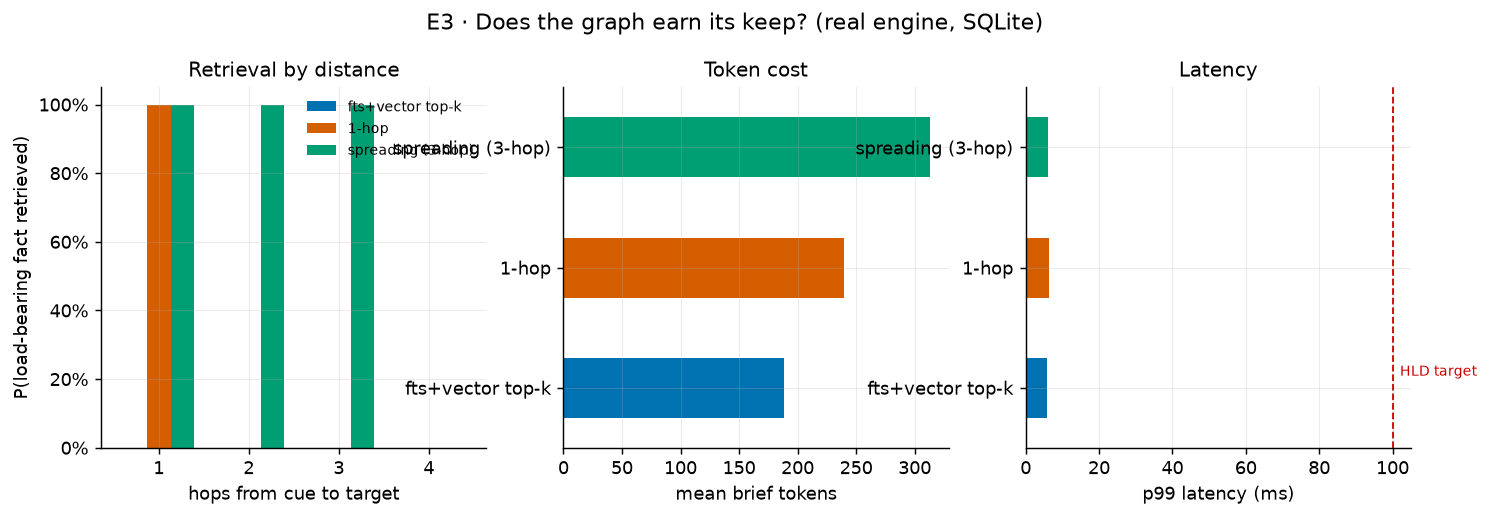

In [4]:
# Does the advantage grow with distance, as §10.3 implies it should?
frames = []
for L in [1, 2, 3, 4]:
    m, pr = build_world(n_chains=30, chain_len=L, n_distractors=250, seed=L)
    d = evaluate(m, pr); d["chain_len"] = L
    frames.append(d)
    m.close()
df_len = pd.concat(frames)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
modes = ["fts+vector top-k", "1-hop", "spreading (3-hop)"]

piv = df_len.groupby(["chain_len", "mode"])["hit"].mean().unstack()
piv = piv[modes]
piv.plot(kind="bar", ax=axes[0], color=PALETTE[:3], width=0.78, legend=False)
axes[0].set_ylabel("P(load-bearing fact retrieved)"); axes[0].set_xlabel("hops from cue to target")
axes[0].set_title("Retrieval by distance"); axes[0].tick_params(axis="x", rotation=0)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].legend(fontsize=8)

df3.groupby("mode")["tokens"].mean().reindex(modes).plot(
    kind="barh", ax=axes[1], color=PALETTE[:3])
axes[1].set_xlabel("mean brief tokens"); axes[1].set_ylabel(""); axes[1].set_title("Token cost")

df3.groupby("mode")["latency_ms"].quantile(0.99).reindex(modes).plot(
    kind="barh", ax=axes[2], color=PALETTE[:3])
axes[2].set_xlabel("p99 latency (ms)"); axes[2].set_ylabel(""); axes[2].set_title("Latency")
axes[2].axvline(100, ls="--", lw=1, color="#c00")
axes[2].text(102, 0.1, "HLD target", fontsize=8, color="#c00")

fig.suptitle("E3 · Does the graph earn its keep? (real engine, SQLite)", y=1.04)
save(fig, "e3_retrieval")

The third panel is the one that can kill the design. HLD §10.2 budgets p99 < 100 ms
for local recall and admits the number is a guess. If spreading activation buys
retrieval accuracy but costs 300 ms, the honest response is to reduce `max_hops` to 2
and say so — not to quietly redefine the target.

wrote figures/e3_latency.png and .pdf
      latency_ms                                          visited             \
           count  mean  std   min   25%   50%   75%   max   count  mean  std   
nodes                                                                          
300         25.0   3.8  0.5   3.2   3.4   3.6   4.1   4.8    25.0  11.2  2.4   
1100        25.0  10.6  0.6   9.9  10.2  10.4  10.8  12.3    25.0  10.0  0.0   
3100        25.0  29.2  1.4  27.2  28.0  28.9  30.1  32.5    25.0  10.0  0.0   
8100        25.0  75.0  2.4  69.0  73.4  75.0  76.9  80.0    25.0  10.0  0.0   

                                     
        min   25%   50%   75%   max  
nodes                                
300    10.0  10.0  10.0  12.0  21.0  
1100   10.0  10.0  10.0  10.0  10.0  
3100   10.0  10.0  10.0  10.0  10.0  
8100   10.0  10.0  10.0  10.0  10.0  


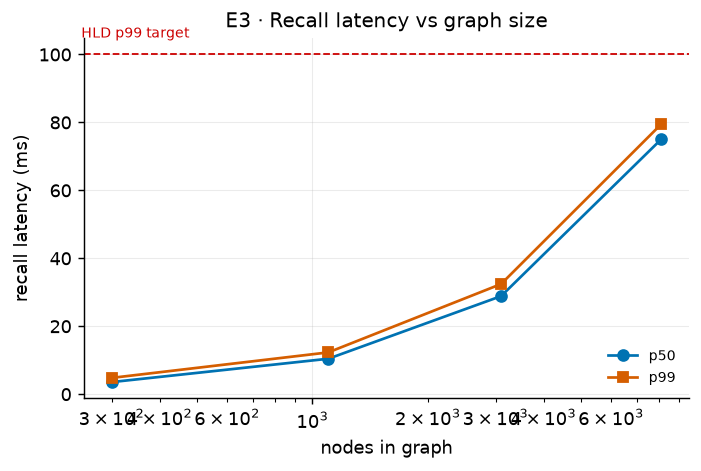

In [5]:
# Latency scaling: p99 against graph size, which is what actually decides
# whether the budget survives contact with a real deployment.
rows = []
for n_dist in [200, 1000, 3000, 8000]:
    m, pr = build_world(n_chains=25, chain_len=3, n_distractors=n_dist, seed=99)
    for p in pr:
        t0 = time.perf_counter()
        r = m.recaller.recall(p["cue"], m.scope, log=False, allow_ablation=False)
        rows.append({"nodes": m.store.count_nodes(m.scope),
                     "latency_ms": (time.perf_counter() - t0) * 1000,
                     "visited": r.visited, "capped": r.hit_visit_cap})
    m.close()
df_lat = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 3.6))
g = df_lat.groupby("nodes")["latency_ms"]
ax.plot(g.median().index, g.median().values, marker="o", color=PALETTE[0], label="p50")
ax.plot(g.quantile(0.99).index, g.quantile(0.99).values, marker="s",
        color=PALETTE[1], label="p99")
ax.axhline(100, ls="--", lw=1, color="#c00"); ax.text(250, 105, "HLD p99 target", fontsize=8, color="#c00")
ax.set_xlabel("nodes in graph"); ax.set_ylabel("recall latency (ms)")
ax.set_xscale("log"); ax.set_title("E3 · Recall latency vs graph size"); ax.legend(fontsize=8)
save(fig, "e3_latency")
print(df_lat.groupby("nodes")[["latency_ms", "visited"]].describe().round(1))

## Findings

1. **Does the hit-rate gap widen with hop distance?** If it does not, spreading
   activation is not buying what §10.3 claims and a hybrid top-k retriever is the
   simpler correct answer.
2. **Does p99 stay inside budget as the graph grows?** Record the node count at
   which it breaks, and whether `visit_cap` is what saves it.
3. **Token cost.** The graph must not win accuracy by simply returning more.